# LSTM Model

The LSTM trains on sliding windows of scaled CPU utilization values.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

from forecast_utils import *
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

df = pd.read_csv(DATA_DIR / 'lstm_data.csv', parse_dates=['timestamp'])
train, test = train_test_split_time(df)
WINDOW = 24
scaler, train_scaled, test_scaled = scale_lstm_data(train['cpu_utilization'].values, test['cpu_utilization'].values)
combined_scaled = np.r_[train_scaled[-WINDOW:], test_scaled]
combined_time = pd.concat([train['timestamp'].iloc[-WINDOW:], test['timestamp']], ignore_index=True)
X_test, y_test_scaled, t_test = make_lstm_sequences(combined_scaled, combined_time, window=WINDOW)
X_train, y_train_scaled, t_train = make_lstm_sequences(train_scaled, train['timestamp'].reset_index(drop=True), window=WINDOW)
print(X_train.shape, X_test.shape)

(7118, 24, 1) (1786, 24, 1)


In [3]:
tf.random.set_seed(42)
model = Sequential([
    LSTM(48, input_shape=(WINDOW, 1)),
    Dropout(0.2),
    Dense(24, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train_scaled, epochs=25, batch_size=64, validation_split=0.15, callbacks=[EarlyStopping(patience=4, restore_best_weights=True)], verbose=1)

Epoch 1/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 9.5306e-04 - val_loss: 5.8407e-04
Epoch 2/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.6014e-04 - val_loss: 5.4469e-04
Epoch 3/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.2405e-04 - val_loss: 5.1932e-04
Epoch 4/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.0134e-04 - val_loss: 4.9984e-04
Epoch 5/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.8460e-04 - val_loss: 4.8549e-04
Epoch 6/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.7245e-04 - val_loss: 4.7508e-04
Epoch 7/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.5387e-04 - val_loss: 4.6731e-04
Epoch 8/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.4211e-04 - val_loss: 4.6254e-04
Epoch 9/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.3864e-04 - val_loss: 4.5928e-04
Epoch 10/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.4767e-04 - val_loss: 4.5954e-04
Epoch 11/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.3411e-0

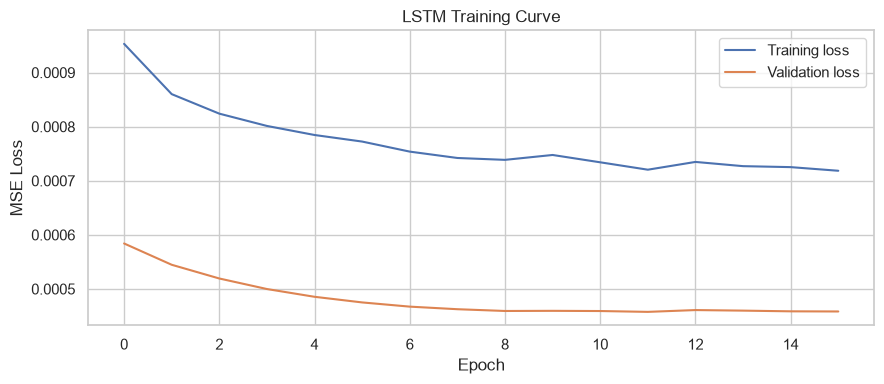

In [4]:
plt.figure(figsize=(9, 4))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('LSTM Training Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lstm_training_curve.png', dpi=160)
plt.show()

In [5]:
pred_scaled = model.predict(X_test).ravel()
pred = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
y_test = scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).ravel()
mse = mean_squared_error(y_test, pred)
metrics = {
    'MAE': mean_absolute_error(y_test, pred),
    'MSE': mse,
    'RMSE': np.sqrt(mse),
    'R2': r2_score(y_test, pred),
}
metrics

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


{'MAE': 0.005052121886202482,
 'MSE': 0.00010380248758649189,
 'RMSE': np.float64(0.010188350582233215),
 'R2': 0.3254122943341742}

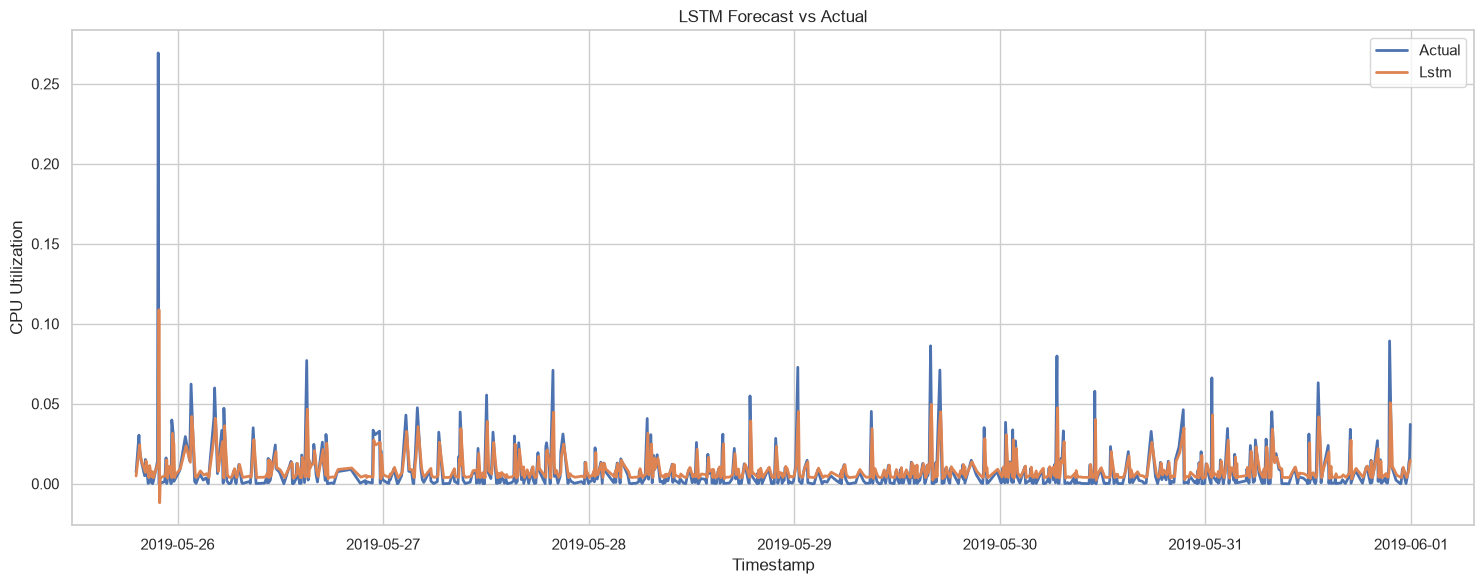

,timestamp,actual,lstm
0,2019-05-25 19:10:00,0.007260,0.004877
1,2019-05-25 19:15:00,0.013036,0.008903
2,2019-05-25 19:20:00,0.018813,0.012782
3,2019-05-25 19:25:00,0.024589,0.016649
4,2019-05-25 19:30:00,0.030365,0.020510


In [6]:
path, pred_df = save_prediction_csv('lstm', t_test, y_test, pred)
plot_actual_predicted(pred_df, 'lstm', 'LSTM Forecast vs Actual', 'lstm_forecast.png')
pred_df.head()